In [4]:
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("heap_benchmark_results.csv")
data.head()

,HeapType,M,Insertions,Removals,Time(ms),MaxPrioritySpilled
0,BinaryHeap,4095,16000,4000,2.065,999589
1,BinaryHeap-Floyd,4095,16000,4000,4.309,999517
2,4aryHeap,4095,16000,4000,3.348,999633
3,4aryHeap-Floyd,4095,16000,4000,3.303,999748
4,BinaryHeap,8190,32000,8000,4.017,999796


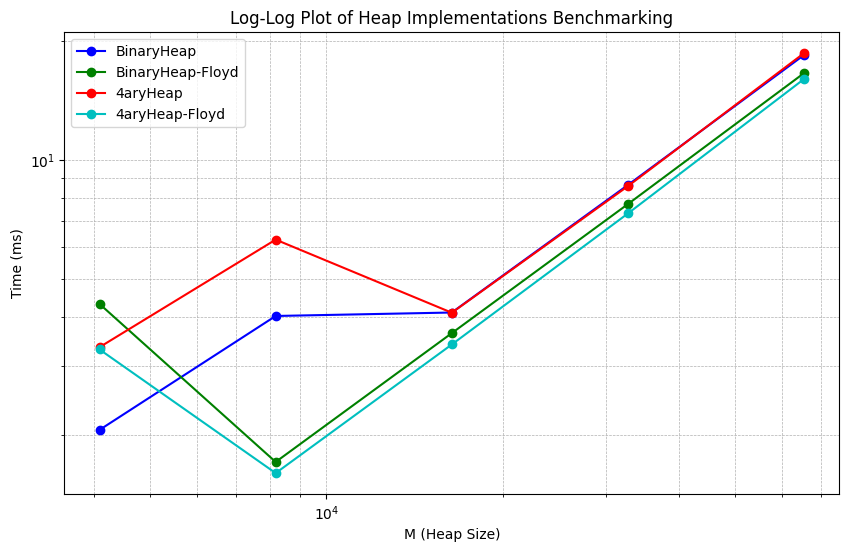

In [5]:

heap_types = data["HeapType"].unique()


plt.figure(figsize=(10, 6))
colors = ["b", "g", "r", "c", "m", "y", "k"]

for i, heap in enumerate(heap_types):
    sub_df = data[data["HeapType"] == heap]
    plt.plot(sub_df["M"], sub_df["Time(ms)"], marker="o", linestyle="-", label=heap, color=colors[i % len(colors)])

plt.xscale("log")
plt.yscale("log")
plt.xlabel("M (Heap Size)")
plt.ylabel("Time (ms)")
plt.title("Log-Log Plot of Heap Implementations Benchmarking")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.show()

in the plot we can see that BinaryHeap-Floyd and 4aryHeap-Floyd are the fastest implementations, both performing consistently better than their corresponding heap structuer without the Floyd's trick. 4-ary heap perform slightly better than their corresponding binary heap implementations when M gets large: when M is smaller, the extra per-node operations in 4-ary heaps make them slightly slower, but they scale better than binary heaps. When M is smaller, we should choose binary heap with Floyd’s trick, and when M gets bigger, and the heap gets deeper, we should choose 4-ary heap with Floyd’s trick. 